<a href="https://colab.research.google.com/github/Ranjan659/Cardamom-leaf-classifier/blob/main/notebooks/01_data_setup_visualizaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cardamom Leaf vs Not-Leaf Classification

## Phase 1: Data Loading Pipeline

### Objectives
In this notebook we will:

1. Connect Google Drive to Colab
2. Load image dataset
3. Apply preprocessing transforms
4. Create batches using DataLoader
5. Visualize sample images

This is the first step before training a CNN model.

In [ ]:
# Mount Google Drive (Robust Connection)
import os
import shutil
from google.colab import drive

# 1. Forcefully unmount the drive in the background
!fusermount -u /content/drive 2>/dev/null || true

# 2. Completely delete the /content/drive directory if it exists
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')
    print("✅ Deleted corrupted /content/drive folder")

# 3. Mount it completely fresh
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Environment Detection Script
import torch
import platform
import psutil
import subprocess

print("="*50)
print("️  SYSTEM SPECIFICATIONS")
print("="*50)

# Hardware
print(f"\n📦 Hardware:")
print(f"   CPU: {platform.processor()}")
print(f"   CPU Cores: {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical")
print(f"   RAM: {round(psutil.virtual_memory().total / (1024**3), 1)} GB")

# Check for GPU
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 1)} GB")
    training_device = "CUDA (GPU)"
else:
    print(f"   GPU: None detected")
    training_device = "CPU"

# Software
print(f"\n💻 Software:")
print(f"   OS: {platform.system()} {platform.release()}")
print(f"   Python: {platform.python_version()}")
print(f"   PyTorch: {torch.__version__}")
print(f"   Training Device: {training_device}")

# Colab-specific info
try:
    import subprocess
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader,nounits'],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print(f"\n🎮 Colab GPU Details:")
        print(f"   {result.stdout.strip()}")
except:
    pass

print("\n" + "="*50)
print("✅ Copy these values into your paper.md")
print("="*50)

️  SYSTEM SPECIFICATIONS

📦 Hardware:
   CPU: x86_64
   CPU Cores: 1 physical / 2 logical
   RAM: 12.7 GB
   GPU: None detected

💻 Software:
   OS: Linux 6.6.122+
   Python: 3.12.13
   PyTorch: 2.11.0+cpu
   Training Device: CPU

✅ Copy these values into your paper.md


# Importing Required Libraries

We import:

- `torch` → Deep learning framework
- `torchvision` → Image datasets and transforms
- `matplotlib` → Visualization
- `os` → File handling

In [ ]:
import os
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility Setup

Deep learning models contain random operations such as:

- weight initialization
- data shuffling
- random sampling

To make experiments reproducible, we set a fixed random seed.

This helps ensure:

- consistent training behavior
- repeatable results
- easier debugging
- research reproducibility

Using the same seed allows the model to produce similar results across multiple runs.

In [ ]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"✅ Random seed set to {SEED}")

✅ Random seed set to 42


# Dataset Setup & Local Copy

The original dataset is stored in Google Drive.
However, reading thousands of small images directly from Drive during training
can crash the connection (`OSError: [Errno 107] Transport endpoint is not connected`).

To fix this and significantly speed up training, we copy the dataset to Colab's local
temporary storage (`/content/`) before loading it.

In [ ]:
import shutil
import os

# 1. Define source (Google Drive) and destination (Colab local storage)
SRC_DRIVE = "/content/drive/MyDrive/cardamom_dataset"
DST_LOCAL = "/content/cardamom_dataset"

# 2. Copy the entire dataset to local Colab storage
if not os.path.exists(DST_LOCAL):
    print("📂 Copying dataset from Drive to local Colab storage...")
    print("   (This takes a minute but prevents Drive crashes and speeds up training!)")
    shutil.copytree(SRC_DRIVE, DST_LOCAL)
    print("✅ Copy complete!")
else:
    print("✅ Dataset already in local storage.")

# 3. UPDATE PATHS TO POINT TO LOCAL STORAGE
TRAIN_PATH = f"{DST_LOCAL}/train"
VAL_PATH = f"{DST_LOCAL}/val"
TEST_PATH = f"{DST_LOCAL}/test"

print(f"\n✅ Training path: {TRAIN_PATH}")
print(f"✅ Validation path: {VAL_PATH}")

📂 Copying dataset from Drive to local Colab storage...
   (This takes a minute but prevents Drive crashes and speeds up training!)
✅ Copy complete!

✅ Training path: /content/cardamom_dataset/train
✅ Validation path: /content/cardamom_dataset/val


# Image Preprocessing

Neural networks require images of the same size.

We apply:

- `Resize(224,224)` → Standard input size
- `ToTensor()` → Converts image into tensor

In [ ]:

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),      # Mirror leaves naturally
    transforms.RandomRotation(degrees=15),        # Slight angle variation
    transforms.ColorJitter(brightness=0.2,        # Lighting changes
                          contrast=0.2),
    transforms.ToTensor(),
])

# Validation/Test transforms (NO augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("✅ Augmentation pipeline configured")
print("   Train: flip, rotation, brightness/contrast jitter")
print("   Val/Test: resize + tensor only")

✅ Augmentation pipeline configured
   Train: flip, rotation, brightness/contrast jitter
   Val/Test: resize + tensor only


#Load Dataset

`ImageFolder` reads all images and assigns labels automatically.

#How `ImageFolder` Works

`ImageFolder` automatically:

- Reads all images inside each folder  
- Uses folder names as class labels  
- Assigns numerical labels automatically

Example:

| Folder Name | Assigned Label |
|---|---|
| `leaf` | `0` |
| `not_leaf` | `1` |

So:

- Every image inside `leaf/` becomes class `0`
- Every image inside `not_leaf/` becomes class `1`

This makes dataset loading very easy for image classification tasks.

In [ ]:
# Load training dataset with augmentation
train_dataset = datasets.ImageFolder(
    root=TRAIN_PATH,
    transform=train_transform
)

# Load validation dataset (no augmentation)
val_dataset = datasets.ImageFolder(
    root=VAL_PATH,
    transform=val_transform
)

print("✅ Train dataset loaded")
print(f"   Classes: {train_dataset.classes}")
print(f"   Total images: {len(train_dataset)}")

print("\n✅ Validation dataset loaded")
print(f"   Total images: {len(val_dataset)}")

✅ Train dataset loaded
   Classes: ['leaf', 'not_leaf']
   Total images: 182

✅ Validation dataset loaded
   Total images: 38


# Create DataLoader

The DataLoader:

- Creates batches
- Shuffles data
- Feeds images during training

Batch size = 8 means:
8 images are processed together.

In [ ]:
# Training DataLoader (with shuffling)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

# Validation DataLoader (no shuffling)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("✅ DataLoaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

✅ DataLoaders created
   Train batches: 23
   Val batches:   5


# Inspect One Batch

We fetch one batch to verify:

- image shape
- labels
- preprocessing

✅ Sample batch from training set
   Shape: torch.Size([8, 3, 224, 224])
   Labels: tensor([1, 0, 0, 1, 1, 1, 0, 0])


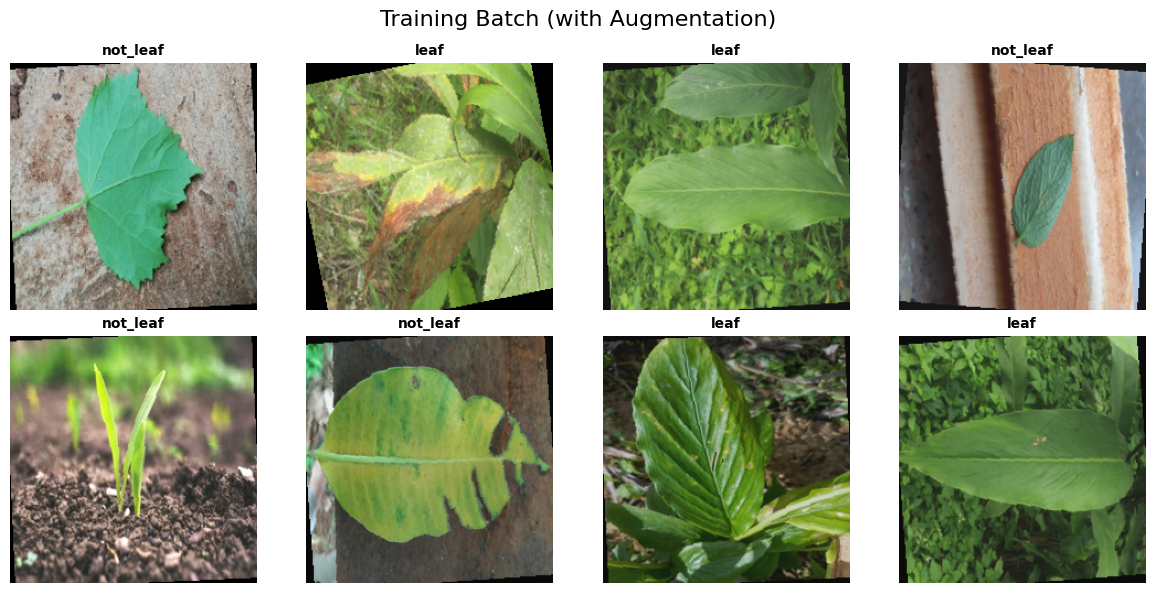


💡 Notice: Images show augmentation effects
   - Random rotations
   - Horizontal flips
   - Brightness/contrast variations


In [ ]:
# Get one batch from training loader
images, labels = next(iter(train_loader))

print("✅ Sample batch from training set")
print(f"   Shape: {images.shape}")
print(f"   Labels: {labels}")

# Visualization function
def tensor_to_image(tensor):
    image = tensor.permute(1, 2, 0)
    image = image.clamp(0, 1)
    return image

# Display 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        ax.imshow(tensor_to_image(images[idx]))
        class_name = train_dataset.classes[labels[idx]]
        ax.set_title(class_name, fontsize=10, fontweight="bold")
        ax.axis("off")

plt.suptitle("Training Batch (with Augmentation)", fontsize=16)
plt.tight_layout()
plt.show()

print("\n💡 Notice: Images show augmentation effects")
print("   - Random rotations")
print("   - Horizontal flips")
print("   - Brightness/contrast variations")

# Visualize Images

PyTorch stores images in this format:

```text
(C, H, W)
```

Where:

- `C` → Color Channels  
  (`3` for RGB images)

- `H` → Image Height  
  (number of pixels vertically)

- `W` → Image Width  
  (number of pixels horizontally)

Example:

```text
(3, 224, 224)
```

means:

- 3 color channels (Red, Green, Blue)
- Height = 224 pixels
- Width = 224 pixels

However, `matplotlib` expects images in this format:

```text
(H, W, C)
```

So we use:

```python
permute(1, 2, 0)
```

to rearrange the dimensions before displaying the image.

# Step 2: Building a Tiny CNN Model

In this step, we create a small Convolutional Neural Network (CNN) for binary image classification.

The model will learn to classify:

- `leaf`
- `not_leaf`

### CNN Architecture

```text
Input Image
      ↓
Convolution Layers
      ↓
ReLU Activation
      ↓
Max Pooling
      ↓
Flatten
      ↓
Fully Connected Layers
      ↓
Prediction Output
```

The network contains:

- 3 Convolution layers → feature extraction
- MaxPooling → reduce image size
- Fully Connected layers → final classification

In [ ]:
# Neural network module
import torch.nn as nn

# Functional operations like ReLU
import torch.nn.functional as F

#Defining CNN Architecture

The CNN learns image patterns step-by-step.

### What each layer does:

| Layer | Purpose |
|---|---|
| Conv2D | Detect features like edges, textures |
| ReLU | Adds non-linearity |
| MaxPool | Reduces image size |
| Flatten | Converts 2D features into 1D vector |
| Linear | Final classification |

The image size changes after pooling:

```text
224 × 224
    ↓
112 × 112
    ↓
56 × 56
    ↓
28 × 28
```

In [ ]:
class TinyCardamomCNN(nn.Module):

    def __init__(self):

        # Initialize parent class
        super(TinyCardamomCNN, self).__init__()

        # Convolution Layers
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        # Pooling Layer

        # Reduces width and height by half
        # Example:
        # 224 → 112
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # Fully Connected Layers


        # After 3 poolings:
        #
        # 224 → 112 → 56 → 28
        #
        # Final tensor:
        # [64, 28, 28]
        #
        # Flattened size:
        # 64 × 28 × 28 = 50176
        self.fc1 = nn.Linear(
            64 * 28 * 28,
            32
        )


        # Final output layer
        #
        # Output:
        # 1 value for binary classification
        self.fc2 = nn.Linear(
            32,
            1
        )


    # Forward Pass

    def forward(self, x):

        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv1(x))
        )

        # Shape:
        # [batch, 16, 112, 112]


        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv2(x))
        )

        # Shape:
        # [batch, 32, 56, 56]


        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv3(x))
        )

        # Shape:
        # [batch, 64, 28, 28]


        # Flatten tensor
        #
        # Example:
        # [8, 64, 28, 28]
        # →
        # [8, 50176]
        x = x.view(-1, 64 * 28 * 28)


        # Fully connected layer
        x = F.relu(self.fc1(x))


        # Final prediction
        x = self.fc2(x)

        return x

# Create Model Instance

Now we create an object of the CNN class.

This initializes all layers and prepares the network for training.

In [ ]:
# Create model object
model = TinyCardamomCNN()

print("✅ Model created successfully!")

# Print architecture
print("\n📊 Model Architecture:\n")
print(model)

✅ Model created successfully!

📊 Model Architecture:

TinyCardamomCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


#Count Model Parameters

Neural networks learn using trainable parameters.

More parameters usually mean:

- more learning capacity
- but also higher risk of overfitting

We calculate:

- Total parameters
- Trainable parameters

In [ ]:
# Count all parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

# Count trainable parameters only
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\n📈 Total parameters: {total_params:,}")
print(f"📈 Trainable parameters: {trainable_params:,}")


📈 Total parameters: 1,629,281
📈 Trainable parameters: 1,629,281


#Testing Forward Pass

Before training, we test whether the model works correctly.

We create a fake image tensor and pass it through the network.

This helps catch shape errors early.

In [ ]:
# Create fake image
#
# Shape:
# [batch, channels, height, width]
test_input = torch.randn(
    1,
    3,
    224,
    224
)

# Pass image through model
output = model(test_input)

print("\n✅ Forward pass successful!")

print(f"\nInput shape: {test_input.shape}")

print(f"Output shape: {output.shape}")

print(
    f"Output value: "
    f"{output.item():.4f}"
)


✅ Forward pass successful!

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 1])
Output value: 0.0466


# Define Loss Function & Optimizer

Before training the CNN, we must define:

- a loss function
- an optimizer

The loss function measures prediction error.

The optimizer updates model weights to reduce that error.

For this binary classification task, we use:

- BCEWithLogitsLoss
- Adam optimizer

Why use BCEWithLogitsLoss instead of BCELoss?

BCELoss expects probability values between 0 and 1.

That means we would first need to apply:

- a Sigmoid activation function

before calculating the loss.

However, BCEWithLogitsLoss is preferred because it:

- automatically applies Sigmoid internally
- is more numerically stable
- reduces floating-point instability
- avoids gradient issues during training

In practice:

- BCELoss = Sigmoid + BCE
- BCEWithLogitsLoss = both combined safely in one function

This is the standard choice for modern binary classification models.

The optimizer used is Adam, which provides:

- adaptive learning rates
- faster convergence
- stable optimization

These settings match Section 3.2 of the research paper.

In [ ]:
# Define Loss Function & Optimizer

criterion = nn.BCEWithLogitsLoss()

# Adam optimizer

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("✅ Loss function initialized")
print("✅ BCEWithLogitsLoss selected")

print("\n✅ Optimizer initialized")
print("✅ Adam optimizer (lr=0.001)")

print("\n🚀 Model ready for training!")

✅ Loss function initialized
✅ BCEWithLogitsLoss selected

✅ Optimizer initialized
✅ Adam optimizer (lr=0.001)

🚀 Model ready for training!


# Training the CNN Model

In this phase, the Convolutional Neural Network (CNN) is trained using batches of cardamom leaf images.

During training, the model performs the following steps for each batch:

1. receives a batch of input images and labels  
2. performs a forward pass to generate predictions  
3. converts logits into prediction probabilities  
4. computes the classification loss using the loss function  
5. calculates prediction accuracy  
6. performs backpropagation to compute gradients  
7. updates model weights using the optimizer  

The training process is repeated for multiple epochs so the model can gradually learn important visual patterns distingushing cardamom leaves from non-leaf backgrounds.

To monitor learning progress, the following metrics are recorded after every epoch:

- training loss  
- training accuracy  

These metrics help evaluate whether the model is learning effectively and can also help identify issues such as overfitting or unstable training behavior.

In [ ]:
import time

print("="*60)
print("🚀 STARTING TRAINING")
print("="*60)

# Configuration
NUM_EPOCHS = 20
BATCH_SIZE = 8

# Metrics tracking
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
patience = 5
trigger_times = 0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # ========== TRAINING PASS ==========
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels.float()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # ========== VALIDATION PASS ==========
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_outputs = model(val_images).squeeze()
            v_loss = criterion(val_outputs, val_labels.float())
            val_loss += v_loss.item()

            val_pred = (torch.sigmoid(val_outputs) > 0.5).float()
            val_correct += (val_pred == val_labels.float()).sum().item()
            val_total += val_labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    # Track metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # ========== EARLY STOPPING ==========
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "/content/best_model.pt")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

    # ========== LOGGING ==========
    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:5.1f}%")

elapsed = time.time() - start_time
print("\n" + "="*60)
print("✅ TRAINING COMPLETE")
print("="*60)
print(f"⏱️  Total time: {elapsed:.1f} seconds")
print(f"🏆 Best validation loss: {best_val_loss:.4f}")

🚀 STARTING TRAINING
Epoch  1 | Train Loss: 0.5451 | Val Loss: 0.0786 | Val Acc: 100.0%
Epoch  2 | Train Loss: 0.1667 | Val Loss: 0.0363 | Val Acc: 100.0%
Epoch  3 | Train Loss: 0.1814 | Val Loss: 0.0572 | Val Acc: 100.0%
Epoch  4 | Train Loss: 0.1220 | Val Loss: 0.0203 | Val Acc: 100.0%
Epoch  5 | Train Loss: 0.1187 | Val Loss: 0.0196 | Val Acc: 100.0%
Epoch  6 | Train Loss: 0.0838 | Val Loss: 0.0273 | Val Acc: 100.0%
Epoch  7 | Train Loss: 0.0823 | Val Loss: 0.0300 | Val Acc:  97.4%
Epoch  8 | Train Loss: 0.0697 | Val Loss: 0.0913 | Val Acc:  97.4%
Epoch  9 | Train Loss: 0.0685 | Val Loss: 0.0513 | Val Acc:  97.4%

⏹️ Early stopping at epoch 10

✅ TRAINING COMPLETE
⏱️  Total time: 406.2 seconds
🏆 Best validation loss: 0.0196


# Visualizing Training Performance

Training curves help us understand how well the model learns.

We plot:

- training loss
- training accuracy

across all epochs.

These graphs help identify:

- learning progress
- convergence
- overfitting issues

The figure is also saved for inclusion in the research paper.


💾 Plot saved to: /content/drive/MyDrive/cardamom_dataset/docs/phase2_curves.png


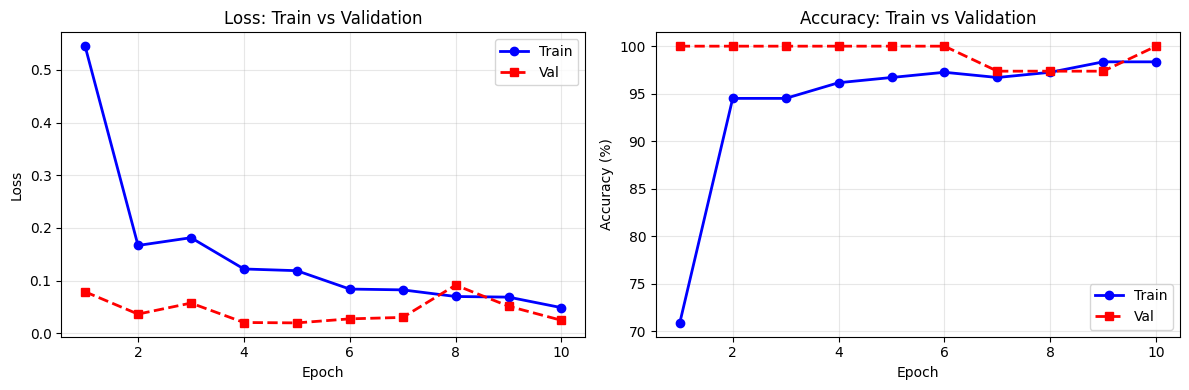

In [ ]:
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss: Train vs Val
axes[0].plot(epochs, train_losses, 'b-', label='Train', linewidth=2, marker='o')
axes[0].plot(epochs, val_losses, 'r--', label='Val', linewidth=2, marker='s')
axes[0].set_title("Loss: Train vs Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy: Train vs Val
axes[1].plot(epochs, train_accuracies, 'b-', label='Train', linewidth=2, marker='o')
axes[1].plot(epochs, val_accuracies, 'r--', label='Val', linewidth=2, marker='s')
axes[1].set_title("Accuracy: Train vs Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save to Drive
save_dir = "/content/drive/MyDrive/cardamom_dataset/docs"
os.makedirs(save_dir, exist_ok=True)
plot_path = f"{save_dir}/phase2_curves.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"\n💾 Plot saved to: {plot_path}")

plt.show()

# Saving Trained Model Weights

After training is complete, we save the learned model weights.

Saving the model allows us to:

- reuse the trained CNN later
- avoid retraining from scratch
- perform inference on new images
- continue training in future experiments

Only the learned parameters (`state_dict`) are saved.

The model is stored:

- locally inside the Colab environment
- inside Google Drive for permanent storage

In [ ]:
# Save Model Weights

import os
import torch

# Save model locally
torch.save(model.state_dict(), "/content/phase1_baseline.pt")

print("✅ Model saved locally")

# Save model to Google Drive
save_dir = (
    "/content/drive/MyDrive/"
    "cardamom_dataset/models"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

model_path = (
    f"{save_dir}/phase1_baseline.pt"
)

torch.save(
    model.state_dict(),
    model_path
)

print("\n✅ Model saved to Drive")
print(model_path)

✅ Model saved locally

✅ Model saved to Drive
/content/drive/MyDrive/cardamom_dataset/models/phase1_baseline.pt


# Downloading Important Files

Finally, we download important experiment outputs for:

- research documentation
- report writing
- GitHub repository upload
- future reuse

The following files are downloaded:

- training curve visualization
- trained CNN model weights

In [ ]:
import torch
import os
from google.colab import files

# STEP 1: delete old file (important)
if os.path.exists("/content/phase1_baseline.pt"):
    os.remove("/content/phase1_baseline.pt")

# STEP 2: re-save clean model
torch.save(model.state_dict(), "/content/phase1_baseline.pt")

# STEP 3: verify file type (must be binary, NOT zip)
print("File exists:", os.path.isfile("/content/phase1_baseline.pt"))
print("File size:", os.path.getsize("/content/phase1_baseline.pt"))

# STEP 4: download
files.download("/content/phase1_baseline.pt")

File exists: True
File size: 6521349


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>